In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [4]:
# Just an empty list to store the data
data_list = []

for i in range(1, 6):
    file_name = f"M13_000{i}.fits"
    
    with fits.open(file_name) as hdul:
        data = hdul[0].data
        data_list.append(data)

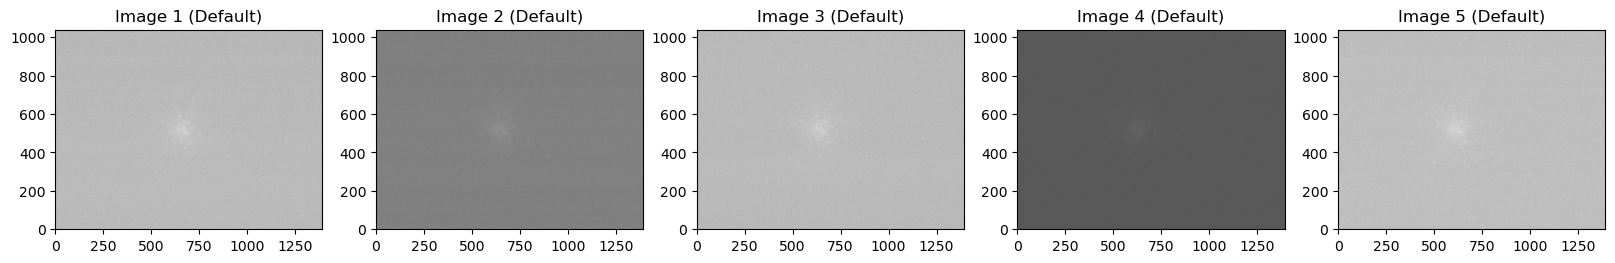

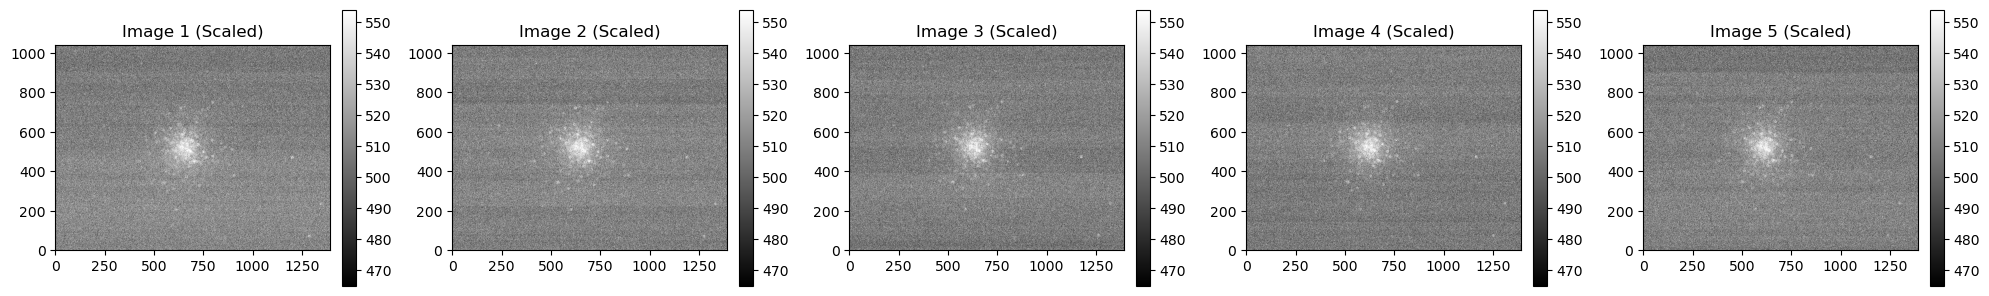

In [5]:
# 3.2 Images
# First set of the subplots
plt.figure(figsize=(20, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(data_list[i], origin="lower", cmap='gray')
    plt.title(f"Image {i+1} (Default)")

# Second set
v_min, v_max = np.percentile(data_list[0], 5), np.percentile(data_list[0], 95)

plt.figure(figsize=(20, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    im = plt.imshow(data_list[i], origin="lower", cmap='gray', vmin=v_min, vmax=v_max)
    plt.title(f"Image {i+1} (Scaled)")
    plt.colorbar(im, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Image 1: Mean=510.47, Median=512.00
Image 2: Mean=509.75, Median=511.00
Image 3: Mean=508.05, Median=510.00
Image 4: Mean=507.91, Median=509.00
Image 5: Mean=508.79, Median=510.00


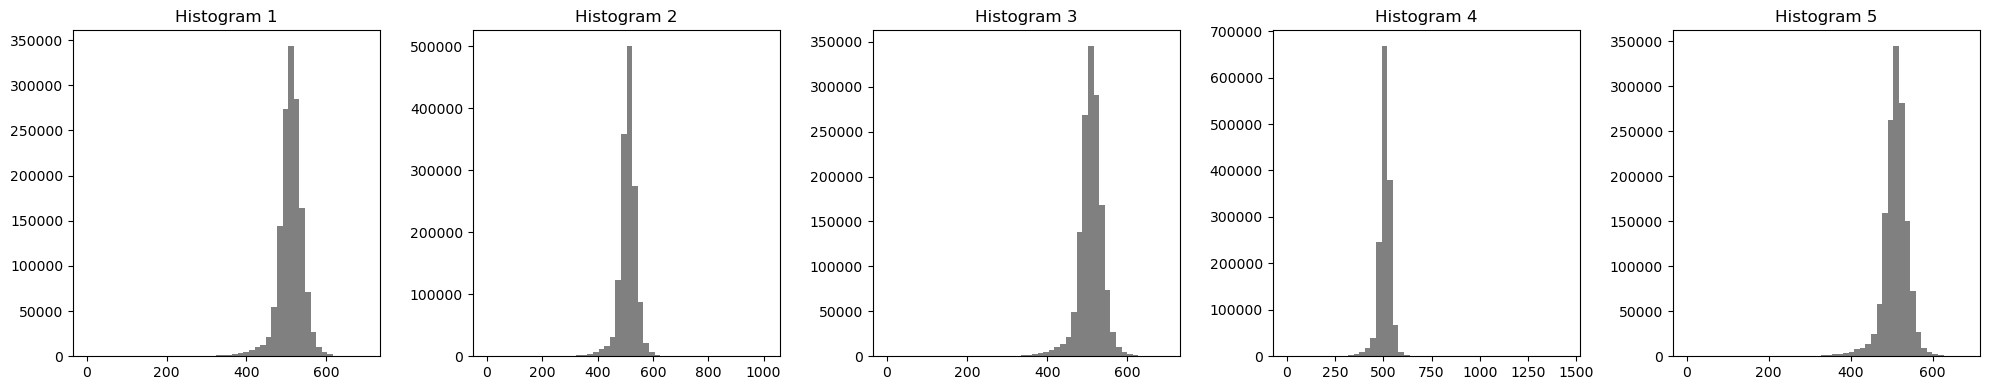

In [6]:
# 3.3 Histograms
plt.figure(figsize=(20, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.hist(data_list[i].ravel(), bins=50, color='gray')
    plt.title(f"Histogram {i+1}")
    
    # Printing stats for part (e)
    mean_val = np.mean(data_list[i])
    median_val = np.median(data_list[i])
    print(f"Image {i+1}: Mean={mean_val:.2f}, Median={median_val:.2f}")

plt.tight_layout()
plt.show()

New median pixel intensity: 510.00


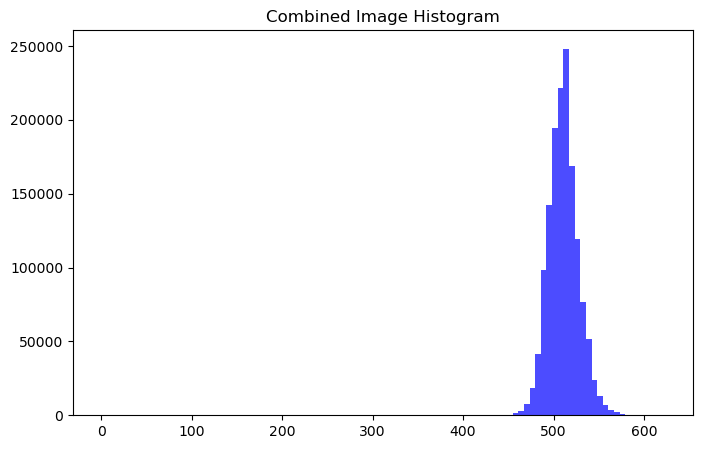

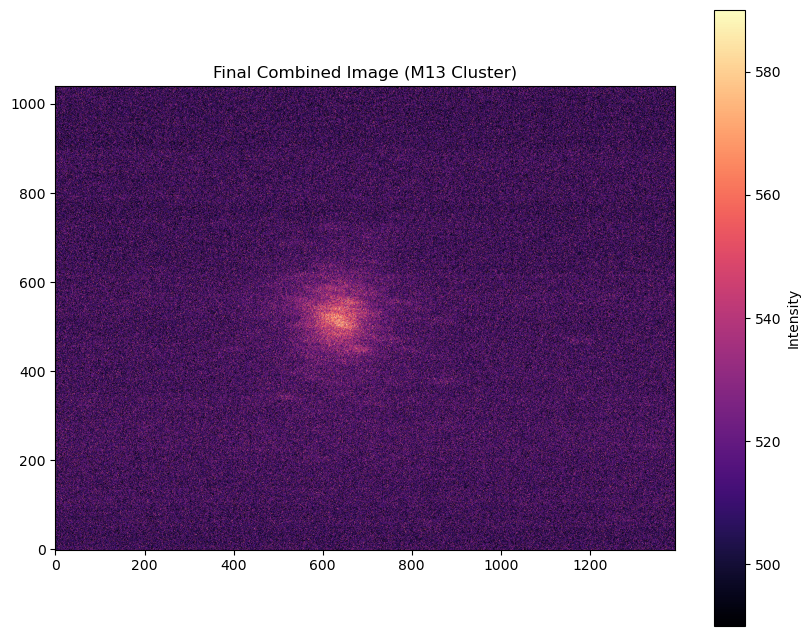

In [11]:
# 3.4 Combining and Normalization
combined_image = np.median(data_list, axis=0)
new_median = np.median(combined_image)
print(f"New median pixel intensity: {new_median:.2f}")


plt.figure(figsize=(8, 5))
plt.hist(combined_image.ravel(), bins=100, color='blue', alpha=0.7)
plt.title("Combined Image Histogram")
plt.show()

# Combined image with vmin/vmax based on the histogram peak (plus using the hint of a diff of 100)
my_vmin = new_median - 20
my_vmax = new_median + 80

plt.figure(figsize=(10, 8))
plt.imshow(combined_image, origin="lower", cmap='magma', vmin=my_vmin, vmax=my_vmax)
plt.title("Final Combined Image (M13 Cluster)")
plt.colorbar(label='Intensity')
plt.show()

fits.writeto("combined.fits", combined_image, overwrite=True)